In [1]:
# For tips on running notebooks in Google Colab, see
# https://docs.pytorch.org/tutorials/beginner/colab
%matplotlib inline

Training a Classifier
=====================

This is it. You have seen how to define neural networks, compute loss
and make updates to the weights of the network.

Now you might be thinking,

What about data?
----------------

Generally, when you have to deal with image, text, audio or video data,
you can use standard python packages that load data into a numpy array.
Then you can convert this array into a `torch.*Tensor`.

-   For images, packages such as Pillow, OpenCV are useful
-   For audio, packages such as scipy and librosa
-   For text, either raw Python or Cython based loading, or NLTK and
    SpaCy are useful

Specifically for vision, we have created a package called `torchvision`,
that has data loaders for common datasets such as ImageNet, CIFAR10,
MNIST, etc. and data transformers for images, viz.,
`torchvision.datasets` and `torch.utils.data.DataLoader`.

This provides a huge convenience and avoids writing boilerplate code.

For this tutorial, we will use the CIFAR10 dataset. It has the classes:
'airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse',
'ship', 'truck'. The images in CIFAR-10 are of size 3x32x32, i.e.
3-channel color images of 32x32 pixels in size.

![cifar10](https://pytorch.org/tutorials/_static/img/cifar10.png)

Training an image classifier
----------------------------

We will do the following steps in order:

1.  Load and normalize the CIFAR10 training and test datasets using
    `torchvision`
2.  Define a Convolutional Neural Network
3.  Define a loss function
4.  Train the network on the training data
5.  Test the network on the test data

### 1. Load and normalize CIFAR10

Using `torchvision`, it's extremely easy to load CIFAR10.


In [2]:
import torch
import torchvision
import torchvision.transforms as transforms

The output of torchvision datasets are PILImage images of range \[0,
1\]. We transform them to Tensors of normalized range \[-1, 1\].


<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTE:</strong></div>

<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">

<p>If you are running this tutorial on Windows or MacOS and encounter aBrokenPipeError or RuntimeError related to multiprocessing, try settingthe num_worker of torch.utils.data.DataLoader() to 0.</p>

</div>



In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# Assuming that we are on a CUDA machine, this should print a CUDA device:
print(device)

cuda:0


In [4]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


C:\Users\luna\KiLaborSS26\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Let us show some of the training images, for fun.


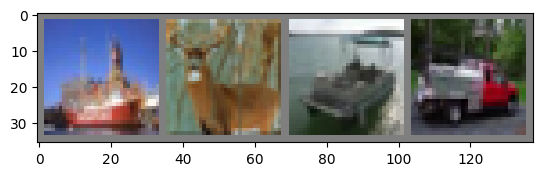

ship  deer  ship  truck


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

2. Define a Convolutional Neural Network
========================================

Copy the neural network from the Neural Networks section before and
modify it to take 3-channel images (instead of 1-channel images as it
was defined).


In [6]:
import torch.nn as nn
import torch.nn.functional as F

class ExampleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

3. Define a Loss function and optimizer
=======================================

Let\'s use a Classification Cross-Entropy loss and SGD with momentum.


4. Train the network
====================

This is when things start to get interesting. We simply have to loop
over our data iterator, and feed the inputs to the network and optimize.


In [7]:

def train_network(net, optimizer, criterion):
    this_device = next(net.parameters())[0].device
    for epoch in range(2):  # loop over the dataset multiple times

        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data
            inputs = inputs.to(this_device)
            labels = labels.to(this_device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            if i % 2000 == 1999:    # print every 2000 mini-batches
                print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f} ({datetime.now()})')
                running_loss = 0.0
    print('Finished Training')

In [8]:
import torch.optim as optim

from datetime import datetime
from models import load_weights, save_weights

EXAMPLE_WEIGHTS = f'./models/cifar_net.pth'

example_net = ExampleNet().to(device)
example_criterion = nn.CrossEntropyLoss()
example_optimizer = optim.SGD(example_net.parameters(), lr=0.001, momentum=0.9)

if load_weights(example_net, EXAMPLE_WEIGHTS):
    print("Loaded weights successfully")
else:
    train_network(net=example_net, criterion=example_criterion, optimizer=example_optimizer)
    save_weights(example_net, EXAMPLE_WEIGHTS)

Loaded weights successfully


See [here](https://pytorch.org/docs/stable/notes/serialization.html) for
more details on saving PyTorch models.

5. Test the network on the test data
====================================

We have trained the network for 2 passes over the training dataset. But
we need to check if the network has learnt anything at all.

We will check this by predicting the class label that the neural network
outputs, and checking it against the ground-truth. If the prediction is
correct, we add the sample to the list of correct predictions.

Okay, first step. Let us display an image from the test set to get
familiar.


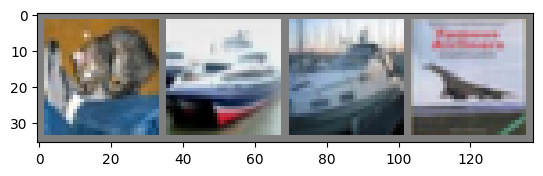

GroundTruth:  cat   ship  ship  plane


In [9]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

Next, let\'s load back in our saved model (note: saving and re-loading
the model wasn\'t necessary here, we only did it to illustrate how to do
so):


Okay, now let us see what the neural network thinks these examples above
are:


In [10]:
outputs = example_net(images.to(device))

The outputs are energies for the 10 classes. The higher the energy for a
class, the more the network thinks that the image is of the particular
class. So, let\'s get the index of the highest energy:


In [11]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  frog  ship  ship  ship 


The results seem pretty good.

Let us look at how the network performs on the whole dataset.


In [12]:
def is_exact_match(pred_tensor:torch.Tensor, y):
    if pred_tensor.dim() == 0:
        return False
    _, pred_y = torch.topk(pred_tensor, 1)
    return pred_y == y

In [13]:
def print_accuracy_on_test(net,
                           is_correct_fn=is_exact_match,
                           testloader=testloader):
    this_device = next(net.parameters())[0].device
    correct = 0
    total = 0
    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(this_device), data[1].to(this_device)
            # calculate outputs by running images through the network
            outputs = net(images)
            # the class with the highest energy is what we choose as prediction
            for label, output in zip(labels, outputs):
                if is_correct_fn(output, label):
                    correct += 1
                total += 1

    print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

In [14]:
print_accuracy_on_test(example_net)

Accuracy of the network on the 10000 test images: 53 %


That looks way better than chance, which is 10% accuracy (randomly
picking a class out of 10 classes). Seems like the network learnt
something.

Hmmm, what are the classes that performed well, and the classes that did
not perform well:


In [15]:
def print_accuracy_per_class(net,
                             is_correct_fn=is_exact_match,
                             testloader=testloader,
                             classes=classes):
    this_device = next(net.parameters())[0].device

    # prepare to count predictions for each class
    correct_pred = {classname: 0 for classname in classes}
    total_pred = {classname: 0 for classname in classes}

    # again no gradients needed
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(this_device), data[1].to(this_device)
            outputs = net(images)
            # collect the correct predictions for each class
            for label, output in zip(labels, outputs):
                if is_correct_fn(output, label):
                    correct_pred[classes[label]] += 1
                total_pred[classes[label]] += 1

    # print accuracy for each class
    for classname, correct_count in correct_pred.items():
        accuracy = 100 * float(correct_count) / total_pred[classname]
        print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

In [16]:
print_accuracy_per_class(example_net)

Accuracy for class: plane is 54.7 %
Accuracy for class: car   is 64.2 %
Accuracy for class: bird  is 40.1 %
Accuracy for class: cat   is 30.7 %
Accuracy for class: deer  is 33.4 %
Accuracy for class: dog   is 38.6 %
Accuracy for class: frog  is 78.0 %
Accuracy for class: horse is 64.1 %
Accuracy for class: ship  is 82.8 %
Accuracy for class: truck is 53.2 %


In [17]:
del dataiter

# Our Model

The network from the example will be used as a baseline

In [18]:
class AssignmentCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Convolution Layer 3x3 depth = 8
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3)

        # Convolution layer 3x3, depth = 16
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3)

        # Max pool 2x2
        self.pool = nn.MaxPool2d(2, 2)

        # Conv layer 3x3, depth 32
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3)

        # Convolution Layer 3x3, depth = 64
        self.conv4 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)

        self.fc1 = nn.Linear(64 * 5 * 5, 4096)
        self.fc2 = nn.Linear(4096, 1000)
        self.fc3 = nn.Linear(1000, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x)


        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [19]:
net = AssignmentCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

if not load_weights(net):
    train_network(net, criterion=criterion, optimizer=optimizer)
    save_weights(net)

Loading latest...


In [20]:
print_accuracy_on_test(net)
print_accuracy_per_class(net)

Accuracy of the network on the 10000 test images: 61 %
Accuracy for class: plane is 68.9 %
Accuracy for class: car   is 75.3 %
Accuracy for class: bird  is 47.4 %
Accuracy for class: cat   is 32.4 %
Accuracy for class: deer  is 35.3 %
Accuracy for class: dog   is 61.4 %
Accuracy for class: frog  is 75.7 %
Accuracy for class: horse is 63.4 %
Accuracy for class: ship  is 73.5 %
Accuracy for class: truck is 77.9 %


# Compare CPU vs GPU

CPU: 17m 57s

GPU: 2m 44s

```py
# CPU
cpu_train_net = AssignmentCNN().to('cpu')
train_network(cpu_train_net,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.SGD(cpu_train_net.parameters(), lr=0.001, momentum=0.9))
```

![image.png](attachment:859bc527-38fb-4bca-9287-536ee650910c.png)

```py
# GPU
gpu_train_net = AssignmentCNN().to('cuda:0')
train_network(gpu_train_net,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.SGD(gpu_train_net.parameters(), lr=0.001, momentum=0.9))
```
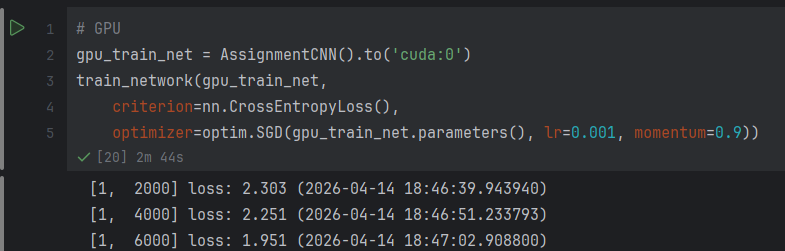

# Change the test metric

In [22]:
def is_in_top_three(pred_tensor, target_label):
    _, top3_pred_y = torch.topk(pred_tensor, 3)
    return target_label in top3_pred_y

In [51]:
def test():
    t = torch.randn(10)
    print(f'input=\n{t}\ntop3=\n{torch.topk(t, 3)}\nfn={is_in_top_three(t, 3)}\n')
test()
test()

input=
tensor([ 0.4566,  0.6834,  0.5110,  0.3891,  0.2120,  0.2190,  0.8354,  0.8086,
        -0.1975, -1.0474])
top3=
torch.return_types.topk(
values=tensor([0.8354, 0.8086, 0.6834]),
indices=tensor([6, 7, 1]))
fn=False

input=
tensor([ 0.8832,  0.3459,  0.8303,  0.9875, -0.7992,  0.8380,  0.8495, -1.0639,
        -0.8847,  1.1125])
top3=
torch.return_types.topk(
values=tensor([1.1125, 0.9875, 0.8832]),
indices=tensor([9, 3, 0]))
fn=True



In [23]:
print_accuracy_on_test(net, is_correct_fn=is_in_top_three)
print_accuracy_on_test(example_net, is_correct_fn=is_in_top_three)

Accuracy of the network on the 10000 test images: 87 %
Accuracy of the network on the 10000 test images: 84 %


In [24]:
print_accuracy_per_class(net, is_correct_fn=is_in_top_three)
print_accuracy_per_class(example_net, is_correct_fn=is_in_top_three)

Accuracy for class: plane is 94.0 %
Accuracy for class: car   is 95.1 %
Accuracy for class: bird  is 84.1 %
Accuracy for class: cat   is 81.0 %
Accuracy for class: deer  is 76.2 %
Accuracy for class: dog   is 87.8 %
Accuracy for class: frog  is 90.1 %
Accuracy for class: horse is 83.0 %
Accuracy for class: ship  is 93.8 %
Accuracy for class: truck is 94.0 %
Accuracy for class: plane is 88.6 %
Accuracy for class: car   is 91.0 %
Accuracy for class: bird  is 81.0 %
Accuracy for class: cat   is 81.0 %
Accuracy for class: deer  is 78.9 %
Accuracy for class: dog   is 74.5 %
Accuracy for class: frog  is 90.0 %
Accuracy for class: horse is 79.2 %
Accuracy for class: ship  is 96.3 %
Accuracy for class: truck is 84.1 %
